In [8]:
import os
dataset_path = "/kaggle/input/datasets/janiherbert/cherry-segmentation-dataset/Cherry Segmentation"
image_dir = dataset_path + "/Original Images"
mask_dir = dataset_path + "/Mask"

0 255
(3456, 3456, 3)
(3456, 3456)
torch.Size([256, 256, 3])
torch.Size([256, 256, 3])
torch.Size([3, 256, 256])


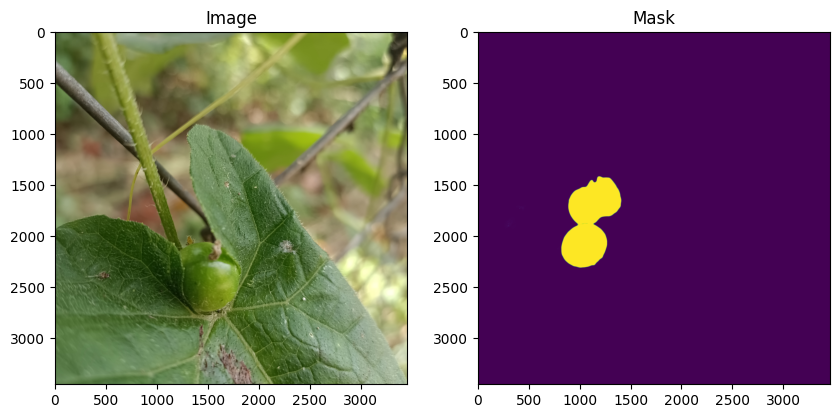

In [9]:
#Visualise One Image And Mask

import cv2
import matplotlib.pyplot as plt

img_path = image_dir + "/" + os.listdir(image_dir)[0]
mask_path = mask_dir + "/" + os.listdir(mask_dir)[0]

image = cv2.imread(img_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path,0)

plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

#Checking Min And Max Of Mask
print(mask.min(),mask.max())

#Normalise
mask = mask/255.0
image = image/255.0

#Check Size Of Image And Mask

print(image.shape)
print(mask.shape)

#Resize
image = cv2.resize(image,(256,256))
mask = cv2.resize(image,(256,256))

#Convert To pyTorch

import torch

image = torch.tensor(image).float()
mask = torch.tensor(mask).float()

print(image.shape)
print(mask.shape)

#Rearrange Image Dimensions

image = image.permute(2,0,1)
print(image.shape)

#No need to permute mask since only 2 dimensions

In [10]:
from torch.utils.data import Dataset
import cv2
import torch

class SegDataSet(Dataset):
    def __init__(self,image_dir,mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
                            
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self,idx):
        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )
        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path,0)
        
        #Resize
        image = cv2.resize(image,(256,256))
        mask = cv2.resize(mask,(256,256))

        #normalise
        image = image/255.0
        mask = mask/255.0

        #Convert To Tensor
        image = torch.tensor(image).float()
        mask = torch.tensor(mask).float()
        
        image = image.permute(2,0,1)
        return image,mask
        


In [11]:
#TEST
dataset = SegDataSet(image_dir,mask_dir)
image,mask = dataset[0]
print(image.shape)

torch.Size([3, 256, 256])


In [12]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size = 4,
    shuffle = True
)

#for im , ma in loader:
#    print(im)
#   print(ma)
#   break

In [13]:
#U-Net
import torch.nn as nn

class DoubleConv(nn.Module):
    
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding = 1),
        nn.ReLU(),

        nn.Conv2d(out_channels,out_channels, 3, padding = 1),
        nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

#Encoder
class Down(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self,x):
        return self.down(x)


#Decoder
class Up(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size = 2,
            stride = 2
        )
        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self,x1,x2):
        x1 = self.up(x1)
        x = torch.cat([x2,x1],dim = 1)
        return self.conv(x)

#Unet
class UNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(3,64)
        self.down1 = Down(64,128)
        self.down2 = Down(128,256)
        self.up1 = Up(256,128)
        self.up2 = Up(128,64)
        self.outc = nn.Conv2d(64,1,kernel_size = 1)

    def forward(self,x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3,x2)
        x = self.up2(x,x1)
        x = self.outc(x)
        return x





In [14]:
#Creating model and connceting to GPU
device = torch.device("cuda")
model = UNET().to(device)


In [15]:
#Loss Function For Single
criterion = nn.BCEWithLogitsLoss()
#Unsqueeze mask
#masks = masks.unsqueeze(1).to(device)
#loss = criterion(outputs,masks)


In [17]:
#Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [19]:
#Training Loop
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs,masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    print(f"Epoch : {epoch+1} - Loss : {avg_loss}")

Epoch : 1 - Loss : 0.14059402763843537
Epoch : 2 - Loss : 0.06355337336659432
Epoch : 3 - Loss : 0.0580677342787385
Epoch : 4 - Loss : 0.05068096201866865
Epoch : 5 - Loss : 0.052009164914488794
